In [184]:
import nibabel as nib
import numpy as np
import os
from matplotlib import pyplot as plt
import eval_utils

In [185]:
# paths.
isles_data_dir = 'ISLES-2022/'
example_case = 66

# Set images path.
flair_path = os.path.join(isles_data_dir, 'sub-strokecase{}'.format("%04d" %example_case), 'ses-0001', 'anat',
                    'sub-strokecase{}_ses-0001_FLAIR.nii.gz'.format("%04d" % example_case))
dwi_path = flair_path.replace('anat', 'dwi').replace('FLAIR', 'dwi')
adc_path = flair_path.replace('anat', 'dwi').replace('FLAIR', 'adc')
mask_path = flair_path.replace(isles_data_dir,isles_data_dir+'derivatives/').replace('/anat', '').replace('FLAIR', 'msk')

In [186]:
print(flair_path)
print(dwi_path)
print(adc_path)
print(mask_path)

ISLES-2022/sub-strokecase0066/ses-0001/anat/sub-strokecase0066_ses-0001_FLAIR.nii.gz
ISLES-2022/sub-strokecase0066/ses-0001/dwi/sub-strokecase0066_ses-0001_dwi.nii.gz
ISLES-2022/sub-strokecase0066/ses-0001/dwi/sub-strokecase0066_ses-0001_adc.nii.gz
ISLES-2022/derivatives/sub-strokecase0066/ses-0001/sub-strokecase0066_ses-0001_msk.nii.gz


In [187]:
# Load image data.
dwi_image = nib.load(dwi_path).get_fdata()
adc_image = nib.load(adc_path).get_fdata()
flair_image = nib.load(flair_path).get_fdata()
mask_image = nib.load(mask_path).get_fdata()

In [188]:
print(flair_image.shape)
print(dwi_image.shape)
print(adc_image.shape)
print(mask_image.shape)

(281, 352, 352)
(112, 112, 73)
(112, 112, 73)
(112, 112, 73)


In [189]:
print(np.unique(mask_image))
np.sum(mask_image == 1)

[0. 1.]


np.int64(8963)

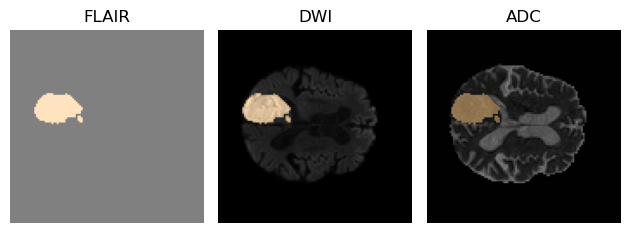

In [190]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

# Show FLAIR image.
# ax1.imshow(flair_image[:,:,16], cmap='gray')
ax1.imshow(mask_image[:,:,slice2show], alpha=0.5, cmap='copper')
ax1.set_title('FLAIR')
ax1.set_axis_off()

slice2show=40
# Show DWI image w/overlayed mask.
ax2.imshow(dwi_image[:,:,slice2show], cmap='gray')
ax2.imshow(mask_image[:,:,slice2show], alpha=0.5, cmap='copper')
ax2.set_title('DWI')
ax2.set_axis_off()

# Show ADC image w/overlayed mask.
ax3.imshow(adc_image[:,:,slice2show], cmap='gray')
ax3.imshow(mask_image[:,:,slice2show], alpha=0.5, cmap='copper')
ax3.set_title('ADC')
ax3.set_axis_off()
plt.tight_layout()
plt.show()

In [191]:
# As an example, we'll segment the DWI using a 99th-percentile intensity cutoff. 
dwi_cutoff = np.percentile(dwi_image[dwi_image>0], 99) 
segmented_image = dwi_image > dwi_cutoff

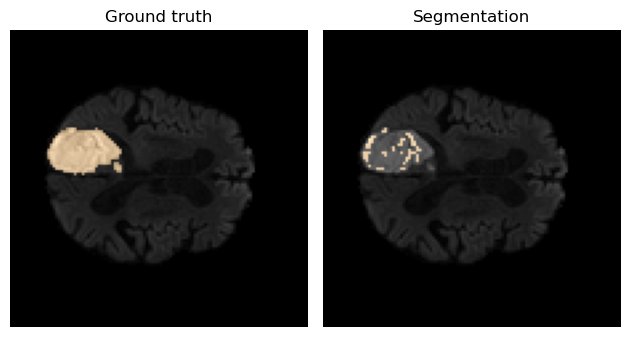

In [192]:
# Lets visualize the segmentation we've created.
# Show ground truth.
fig2, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(dwi_image[:,:,slice2show], cmap='gray')
ax1.imshow(mask_image[:,:,slice2show], alpha=0.5, cmap='copper')
ax1.set_title('Ground truth')
ax1.set_axis_off()

# Show predicted segmentation.
ax2.imshow(dwi_image[:,:,slice2show], cmap='gray')
ax2.imshow(segmented_image[:,:,slice2show], alpha=0.5, cmap='copper')
ax2.set_title('Segmentation')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

In [193]:
# Compute performance metrics.
# Compute dice
print('Dice score: {}'.format(eval_utils.compute_dice(mask_image, segmented_image)))

# Compute absolute volume difference
voxel_volume = np.prod(nib.load(dwi_path).header.get_zooms())/1000 # Get voxel volume
print('Absolute volume difference: {} ml'.format(eval_utils.compute_absolute_volume_difference(mask_image, segmented_image, voxel_volume)))

# Compute absolute lesion count difference
print('Absolute lesion count difference: {} '.format(eval_utils.compute_absolute_lesion_difference(mask_image, segmented_image)))

# Compute F1-score (lesion-wise)
print('Lesion-wise F1-score: {} '.format(eval_utils.compute_lesion_f1_score(mask_image, segmented_image)))

Dice score: 0.31455660903513666
Absolute volume difference: 57.34400272369385 ml
Absolute lesion count difference: 36 
Lesion-wise F1-score: 0.11764705882352941 
